<a href="https://colab.research.google.com/github/Suhani12389/Major-Project-By-Suhani-Krishna/blob/main/APK_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn as sk

In [ ]:
df = pd.read_excel('/content/feature_vectors_syscalls_frequency_5_Cat.xlsx')

Class
3    3904
4    2546
2    2100
5    1795
1    1253
Name: count, dtype: int64


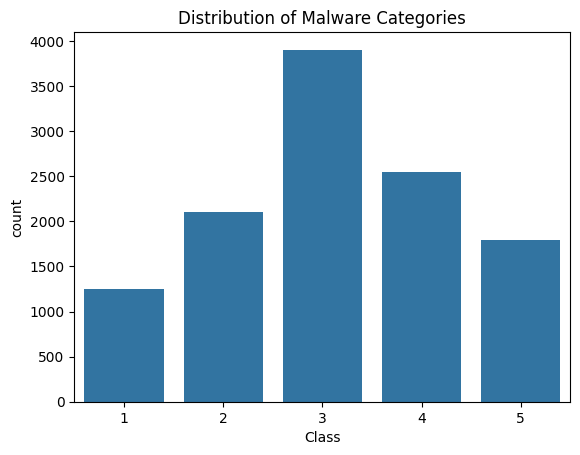

In [ ]:
print(df['Class'].value_counts())
sns.countplot(x='Class', data=df)
plt.title('Distribution of Malware Categories')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class'].apply(lambda x: 0 if x == 1 else 1) # Assuming Class 1 is 'Benign' for binary logic example

In [ ]:
# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 3. Train the Model
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
# 4. Get Results
predictions = model.predict(X_test)
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[ 195   67]
 [   8 2050]]
              precision    recall  f1-score   support

           0       0.96      0.74      0.84       262
           1       0.97      1.00      0.98      2058

    accuracy                           0.97      2320
   macro avg       0.96      0.87      0.91      2320
weighted avg       0.97      0.97      0.97      2320



<Axes: >

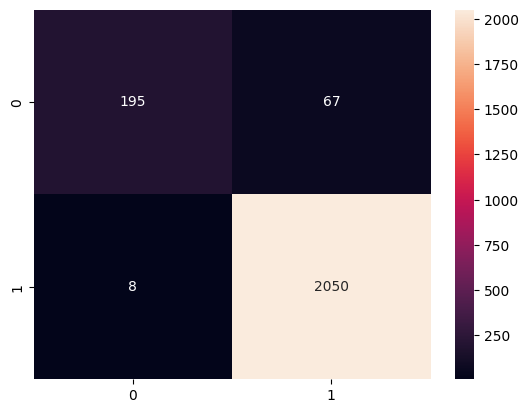

In [ ]:
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Step 1: Split the data (80% Training, 20% Testing)
# Assuming 'Class' is your label column based on the existing DataFrame
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Initialize and Train the Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 3: Make Predictions
y_pred = model.predict(X_test)

# Step 4: Output Results for your Report
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.930603448275862

Classification Report:
               precision    recall  f1-score   support

           1       0.86      0.87      0.87       262
           2       0.96      0.89      0.92       424
           3       0.97      0.99      0.98       786
           4       0.93      0.92      0.92       500
           5       0.86      0.91      0.89       348

    accuracy                           0.93      2320
   macro avg       0.92      0.92      0.92      2320
weighted avg       0.93      0.93      0.93      2320



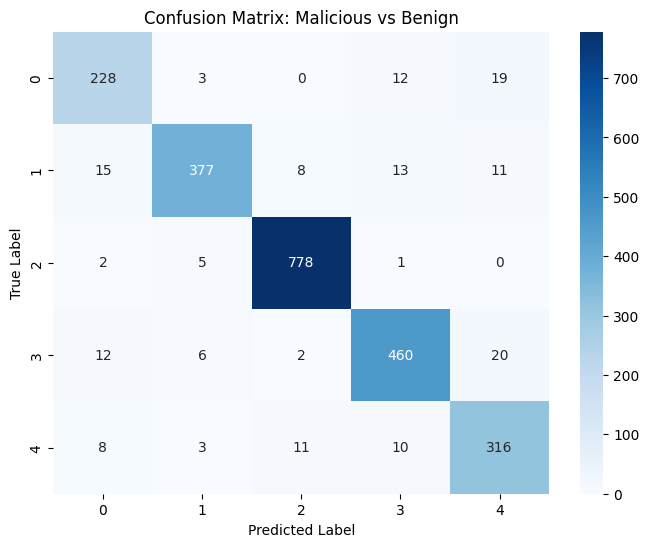

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize it
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Malicious vs Benign')
plt.show()

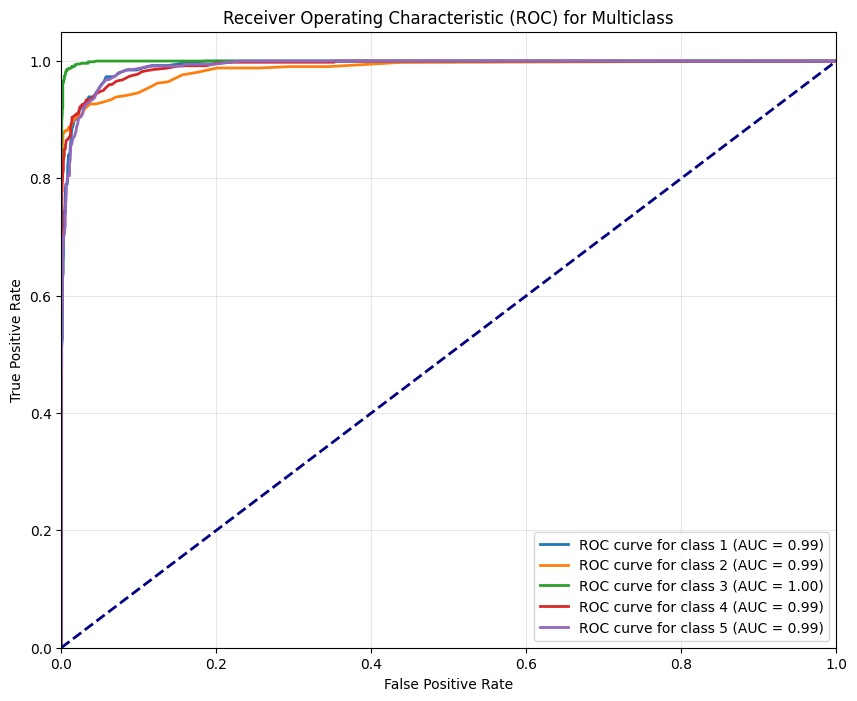

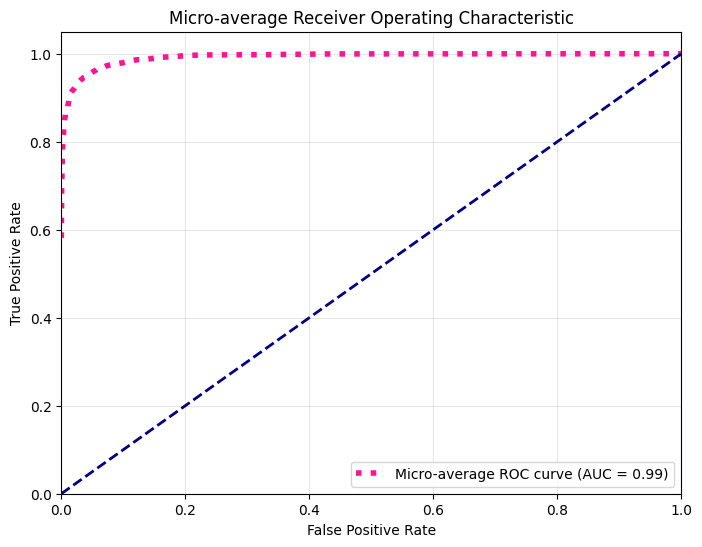

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# 1. Get prediction probabilities
# For multiclass, model.predict_proba(X_test) returns probabilities for each class
y_probs_all_classes = model.predict_proba(X_test)

# Get unique classes from y_test
classes = np.unique(y_test)
n_classes = len(classes)

# Binarize y_test for One-vs-Rest approach
y_test_binarized = label_binarize(y_test, classes=classes)

# Store False Positive Rate, True Positive Rate, and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    # Calculate ROC curve for each class
    # Use y_test_binarized[:, i] as the true binary labels for class i
    # Use y_probs_all_classes[:, i] as the prediction probabilities for class i
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_probs_all_classes[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f'ROC curve for class {classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for Multiclass')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Optional: Micro-average ROC curve and AUC
# Aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Interpolate all ROC curves at these points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Average it and compute AUC
mean_tpr /= n_classes

fpr_micro = all_fpr
tpr_micro = mean_tpr
roc_auc_micro = auc(fpr_micro, tpr_micro)

plt.figure(figsize=(8, 6))
plt.plot(fpr_micro, tpr_micro,
         label=f'Micro-average ROC curve (AUC = {roc_auc_micro:.2f})',
         color='deeppink', linestyle=':', lw=4)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Micro-average Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

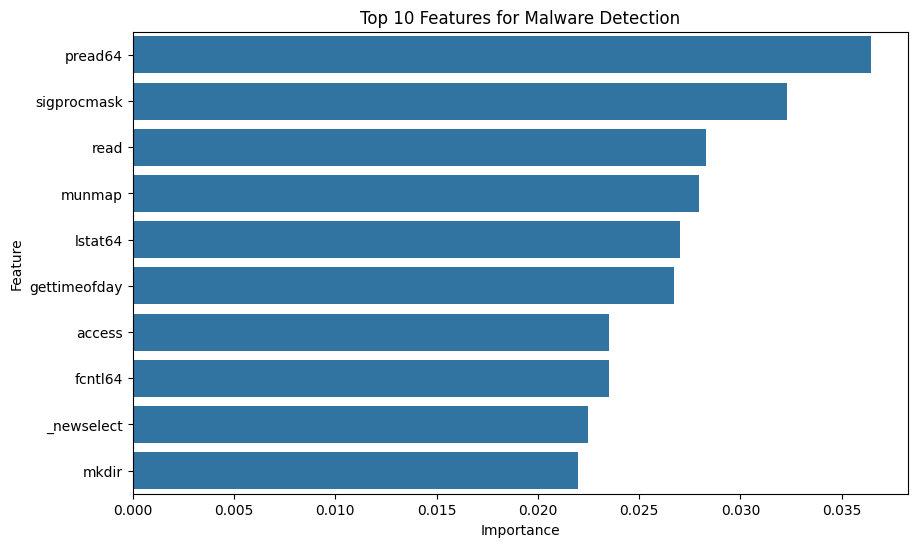

In [ ]:
# Get feature importances from your Random Forest model
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Top 10 Features for Malware Detection')
plt.show()


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Train a second model
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
dt_acc = dt_model.score(X_test, y_test)

# Calculate Random Forest Accuracy
rf_acc = model.score(X_test, y_test)

print(f"Random Forest Accuracy: {rf_acc}")
print(f"Decision Tree Accuracy: {dt_acc}")

Random Forest Accuracy: 0.930603448275862
Decision Tree Accuracy: 0.8969827586206897


In [ ]:
def check_apk(features):
    prediction = model.predict([features])
    if prediction[0] == 1:
        return "⚠️ ALERT: This APK is Malicious!"
    else:
        return "✅ This APK is Benign."